In [1]:
# /opt/local/bin/python3.13 test.py
import sys, string, os
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
from scipy.interpolate import griddata
plt.rcParams['text.usetex'] = True
sys.path.append("../../python")
from modlibUtils import *
from stereoUtils import *
sys.path.append("../../build/tools/pyMoDELib")
import pyMoDELib

In [2]:
def resolved_shear_stress_tensor(resolved_shear, b_unit, n_unit):
    S = np.outer(b_unit, n_unit) + np.outer(n_unit, b_unit)  # symmetric shear tensor
    # S /= np.linalg.norm(S)  # normalize to unit Frobenius norm DONT NORMALIZE TENSOR
    return resolved_shear * S

def compute_rotation_matrix(x1_norm,x3_norm):
    x3_dir = x3_norm
    x1_dir = x1_norm - np.dot(x1_norm, x3_dir) * x3_dir # orthogonalize x1 to x3
    x2_dir = np.cross(x3_dir, x1_dir)
    return np.row_stack((x1_dir, x2_dir, x3_dir))

def modify_variable_in_file(file_path, variable_name, new_value):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    for i, line in enumerate(lines):
        stripped_line = line.strip()
        if stripped_line.startswith(variable_name + "="):
            # Find the position of '='
            eq_index = line.find('=')
            # Find the position of the semicolon (comment start)
            semi_index = line.find(';', eq_index)
            if semi_index != -1:
                # Replace value and preserve everything after the semicolon
                lines[i] = line[:eq_index + 1] + f"{new_value}" + line[semi_index:]  # keep ; and comments
            else:
                # No comment, just end line with semicolon
                lines[i] = line[:eq_index + 1] + f"{new_value};\n"
            break  # stop after modifying the first match
    with open(file_path, 'w') as file:
        file.writelines(lines)

In [ ]:
# --------- Initialize ---------
materialFile="../../Library/Materials/WRe.txt" # material file
b_SI=getValueInFile(materialFile,'b_SI')
mu0_SI=getValueInFile(materialFile,'mu0_SI')
rho_SI=getValueInFile(materialFile,'rho_SI')
cs = np.sqrt(mu0_SI/rho_SI)  
t_dd2SI = b_SI / cs     
tauC_SI=getValueInFile(materialFile,'tauC_SI') # critical shear stress ?
print(tauC_SI)


x1=np.array([1,1,1]) # x1 crystal direction
x1=x1/np.linalg.norm(x1); 
b=np.array([1,1,1]) # burgers vector
b=b/np.linalg.norm(b)
n=np.array([-1,0,1]) # plane normal
n=n/np.linalg.norm(n)

# T_array = [100, 300, 500, 700, 1000]  # K
# s0_array = np.linspace(0.01, 0.6, 1000)/mu0_SI/1e-9
# c_sol_array = [0.01, 0.03, 0.1]



T_array = [150, 300, 450, 600]  # K
s0_array = np.linspace(0.01, 1.0, 1000)/mu0_SI/1e-9
c_sol_array = [0.0, 0.03, 0.07, 0.15, 0.30]

# exprimental strain rate range from paper
rho_m = 1e12                  # m^-2 from Curtin paper
b_mag = b_SI                   # Burgers magnitude (m)
epsdot_low  = 5.5e-4
epsdot_high = 8.3e-4
v_target_low  = epsdot_low  / (rho_m * b_mag)
v_target_high = epsdot_high / (rho_m * b_mag)
print("v_target_low  =", v_target_low,  "m/s")
print("v_target_high =", v_target_high, "m/s")


velo_t_c = {}
stress_axis_GPa = s0_array * mu0_SI * 1e-9
for i, c_sol in enumerate(c_sol_array):
    # ---- set material composition once per subplot ----
    velo_t_c[c_sol] = {}
    modify_variable_in_file(materialFile, 'c_sol', c_sol)

    for T in T_array:
        mat = pyMoDELib.PolycrystallineMaterialBase(materialFile, T)
        DDPy = "../../python/MobilityLaw/DDMobilityPy"
        mobPy = pyMoDELib.DislocationMobilityPy(mat, DDPy)

        velocities = []
        for s0 in s0_array:
            S_crystal = resolved_shear_stress_tensor(s0, b, n)
            C2G = compute_rotation_matrix(x1, n)
            S_global = C2G @ S_crystal @ C2G.T

            v = mobPy.velocity(S_global, C2G @ b, C2G @ x1, C2G @ n, T)
            v_si = v * cs
            velocities.append(v_si) 

        # store as numpy array
        velo_t_c[c_sol][T] = np.array(velocities)
        # plt.plot(s0_array*mu0_SI*1e-9, velocities, label=f"{int(c_sol*100)} at.% Re")


# Plot for each temperature in a separate subplot
nT = len(T_array)
fig, axes = plt.subplots(1, nT, figsize=(5*nT, 5), sharey=False)
# If only one temperature, axes is not iterable → fix that
if nT == 1:
    axes = [axes]
for i, T in enumerate(T_array):
    ax = axes[i]
    # plot concentration curves
    for c_sol in c_sol_array:
        v = velo_t_c[c_sol][T]
        ax.plot(stress_axis_GPa, v, label=f"{int(round(c_sol*100))} at.% Re")
    ax.axhline(v_target_low,  color='k', linestyle='--', linewidth=1.8)
    # ax.axhline(v_target_high, color='k', linestyle=':',  linewidth=1.8)
    ax.set_title(f"{int(T)} K", fontsize=18)
    ax.set_xlabel("RSS [GPa]", fontsize=18)
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=14)
axes[0].set_ylabel("Dislocation velocity [m/s]", fontsize=18)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           ncol=1,
           frameon=True,
           fontsize=14,
           bbox_to_anchor=(0.25, 0.45))
# plt.tight_layout()
plt.savefig("Figures/WRe_velocity_vs_stress.png", dpi=300)
plt.show()

# plt.figure(figsize=(6,5))
# # ---- Add experimental velocity band ----
# plt.axhline(v_target_low,  color='k', linestyle='--', linewidth=2, label=r"$v_{target}$ (5.5e-4 s$^{-1}$)")
# plt.axhline(v_target_high, color='k', linestyle=':', linewidth=2, label=r"$v_{target}$ (8.3e-4 s$^{-1}$)")

# plt.xlabel("Resolved Shear Stress [GPa]")
# plt.ylabel("Dislocation velocity [m/s]")
# plt.yscale("log")
# plt.grid(True)
# plt.legend()
# plt.title("Velocity vs stress at 300 K")

# plt.tight_layout()
# plt.show()



1100000000.0
v_target_low  = 2.0205731080088172e-06 m/s
v_target_high = 3.0492285084496695e-06 m/s
Reading material file ../../Library/Materials/WRe.txt
materialName=W 
crystalStructure=BCC 
atomsPerUnitCell=1 
Tm=3695 # [K]		melting temperature
mu0_SI=1.61e+11 # [Pa] 		temperature-independent shear modulus coeff in mu=mu0+mu1*T
mu1_SI=0 # [Pa/K] 	temperature-dependent shear modulus coeff in mu=mu0+mu1*T
nu=0.28 # [-]		Poisson's ratio
rho_SI=19250 # [kg/m^3]	mass density
b_SI=2.722e-10 # [m] 		Burgers vector magnitude 
enabledSlipSystems=full<111>{110} # types of slip systems enabled e.g. enabledSlipSystems=full<111>{110} and/or full<100>{110};
enabledSecondPhases= sigma chi 
  temperature: T=150 [K]
  units of stress (shear modulus): mu=1.61e+11 [Pa]
  units of length (Burgers vector): b=2.722e-10 [m]
  units of speed (shear-wave speed): cs=2892 [m/s]
  units of time: b/cs=9.41219e-14 [sec]
Enabled SlipSystems
full<111>{110}
Enabled SecondPhases
chi
sigma
Creating DislocationMobility 

/Users/matthewmaron/Documents/MoDELib2-LANL/tests/WRe/../../python/MobilityLaw/DDMobilityPy.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  term = tau / tc + 2.7 / np.sqrt(L/b)


T 300.0 c_sol 0.0 tau(GPa) 0.996036036036036 Hdk_eV 0.20291471668221056 t_n 7.049850516827883e-11
T 300.0 c_sol 0.0 tau(GPa) 0.997027027027027 Hdk_eV 0.2025360542178583 t_n 6.947341686200671e-11
T 300.0 c_sol 0.0 tau(GPa) 0.9980180180180183 Hdk_eV 0.20215787225808937 t_n 6.846450644257229e-11
T 300.0 c_sol 0.0 tau(GPa) 0.9990090090090091 Hdk_eV 0.20178017017576336 t_n 6.74715001011094e-11
T 300.0 c_sol 0.0 tau(GPa) 0.9999999999999999 Hdk_eV 0.201402947345396 t_n 6.649412895839237e-11
Reading material file ../../Library/Materials/WRe.txt
materialName=W 
crystalStructure=BCC 
atomsPerUnitCell=1 
Tm=3695 # [K]		melting temperature
mu0_SI=1.61e+11 # [Pa] 		temperature-independent shear modulus coeff in mu=mu0+mu1*T
mu1_SI=0 # [Pa/K] 	temperature-dependent shear modulus coeff in mu=mu0+mu1*T
nu=0.28 # [-]		Poisson's ratio
rho_SI=19250 # [kg/m^3]	mass density
b_SI=2.722e-10 # [m] 		Burgers vector magnitude 
enabledSlipSystems=full<111>{110} # types of slip systems enabled e.g. enabledSlipSys

In [ ]:
def velocity_at_s0(mobPy, s0, b, n, x1, C2G, T, cs):
    """Compute SI velocity for given normalized stress amplitude s0."""
    S_crystal = resolved_shear_stress_tensor(s0, b, n)
    S_global  = C2G @ S_crystal @ C2G.T
    v = mobPy.velocity(S_global, C2G @ b, C2G @ x1, C2G @ n, T)
    return float(v) * cs  # SI

def bracket_for_target(mobPy, s0_grid, v_target, b, n, x1, C2G, T, cs):
    """
    Find [s_lo, s_hi] such that v(s_lo) <= v_target <= v(s_hi).
    Assumes v increases with s0.
    """
    v_prev = velocity_at_s0(mobPy, s0_grid[0], b, n, x1, C2G, T, cs)
    if v_prev >= v_target:
        return s0_grid[0], s0_grid[0]  # already above at the left edge

    for k in range(1, len(s0_grid)):
        v_curr = velocity_at_s0(mobPy, s0_grid[k], b, n, x1, C2G, T, cs)
        if v_curr >= v_target:
            return s0_grid[k-1], s0_grid[k]
        v_prev = v_curr

    # never crossed
    return None, None

def bisect_crss(mobPy, s_lo, s_hi, v_target, b, n, x1, C2G, T, cs,
                tol_rel=1e-4, max_iter=80):
    """
    Bisection solve for v(s)=v_target on log scale.
    Returns s* (same units as s0).
    """
    # handle degenerate bracket
    if s_lo == s_hi:
        return s_lo

    def g(s):
        v = velocity_at_s0(mobPy, s, b, n, x1, C2G, T, cs)
        # log residual is numerically stable
        return np.log(v + 1e-300) - np.log(v_target)

    g_lo = g(s_lo)
    g_hi = g(s_hi)

    # must bracket root
    if g_lo > 0 and g_hi > 0:
        return None
    if g_lo < 0 and g_hi < 0:
        return None

    for _ in range(max_iter):
        s_mid = 0.5 * (s_lo + s_hi)
        g_mid = g(s_mid)

        # shrink interval
        if g_mid >= 0:
            s_hi = s_mid
            g_hi = g_mid
        else:
            s_lo = s_mid
            g_lo = g_mid

        # stopping criterion (relative interval size)
        if abs(s_hi - s_lo) / max(abs(s_hi), 1e-30) < tol_rel:
            return 0.5 * (s_lo + s_hi)

    return 0.5 * (s_lo + s_hi)

In [ ]:
# ---------------------------
# user inputs
# ---------------------------
materialFile = "../../Library/Materials/WRe.txt"
b_SI   = getValueInFile(materialFile,'b_SI')
mu0_SI = getValueInFile(materialFile,'mu0_SI')
rho_SI = getValueInFile(materialFile,'rho_SI')
cs     = np.sqrt(mu0_SI / rho_SI)

x1 = np.array([1,1,1], dtype=float); x1 /= np.linalg.norm(x1)
b  = np.array([1,1,1], dtype=float); b  /= np.linalg.norm(b)
n  = np.array([-1,0,1], dtype=float); n  /= np.linalg.norm(n)

C2G = compute_rotation_matrix(x1, n)  # constant for your setup

T_array     = [185, 300, 435, 590, 730]          # match Curtin figure temps if you want
c_sol_array = np.arange(0.0, 0.25, 0.01)  # 0.00 to 0.30

# experimental strain-rate range from Curtin text
rho_m = 1e12
epsdot_low, epsdot_high = 5.5e-4, 8.3e-4
v_target_low  = epsdot_low  / (rho_m * b_SI)
v_target_high = epsdot_high / (rho_m * b_SI)

# stress search domain (same units you used before)
s0_grid = np.linspace(0.01, 1.0, 120) / mu0_SI / 1e-9  # coarse grid for bracketing

DDPy = "../../python/MobilityLaw/DDMobilityPy"

# ---------------------------
# compute CRSS(T) for each c_sol
# ---------------------------
CRSS_low  = {c: [] for c in c_sol_array}
CRSS_high = {c: [] for c in c_sol_array}

for c_sol in c_sol_array:
    modify_variable_in_file(materialFile, 'c_sol', c_sol)
    for T in T_array:
        mat = pyMoDELib.PolycrystallineMaterialBase(materialFile, T)
        mobPy = pyMoDELib.DislocationMobilityPy(mat, DDPy)

        # --- low target ---
        lo, hi = bracket_for_target(mobPy, s0_grid, v_target_low, b, n, x1, C2G, T, cs)
        if lo is None:
            CRSS_low[c_sol].append(np.nan)
        else:
            s_star = bisect_crss(mobPy, lo, hi, v_target_low, b, n, x1, C2G, T, cs)
            CRSS_low[c_sol].append(np.nan if s_star is None else s_star * mu0_SI * 1e-9)  # -> GPa

        # --- high target ---
        lo, hi = bracket_for_target(mobPy, s0_grid, v_target_high, b, n, x1, C2G, T, cs)
        if lo is None:
            CRSS_high[c_sol].append(np.nan)
        else:
            s_star = bisect_crss(mobPy, lo, hi, v_target_high, b, n, x1, C2G, T, cs)
            CRSS_high[c_sol].append(np.nan if s_star is None else s_star * mu0_SI * 1e-9)  # -> GPa

/Users/matthewmaron/Documents/MoDELib2-LANL/tests/WRe/../../python/MobilityLaw/DDMobilityPy.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  term = tau / tc + 2.7 / np.sqrt(L/b)


Reading material file ../../Library/Materials/WRe.txtT 185.0 c_sol 0.0 tau(GPa) 0.01 chi 1.8600261130154034 Em(eV) 0.0 t_k 8.242620036324839e-09

materialName=W 
crystalStructure=BCC 
atomsPerUnitCell=1 
Tm=3695 # [K]		melting temperature
mu0_SI=1.61e+11 # [Pa] 		temperature-independent shear modulus coeff in mu=mu0+mu1*T
mu1_SI=0 # [Pa/K] 	temperature-dependent shear modulus coeff in mu=mu0+mu1*T
nu=0.28 # [-]		Poisson's ratio
rho_SI=19250 # [kg/m^3]	mass density
b_SI=2.722e-10 # [m] 		Burgers vector magnitude 
enabledSlipSystems=full<111>{110} # types of slip systems enabled e.g. enabledSlipSystems=full<111>{110} and/or full<100>{110};
enabledSecondPhases= sigma chi 
  temperature: T=185 [K]
  units of stress (shear modulus): mu=1.61e+11 [Pa]
  units of length (Burgers vector): b=2.722e-10 [m]
  units of speed (shear-wave speed): cs=2892 [m/s]
  units of time: b/cs=9.41219e-14 [sec]
Enabled SlipSystems
full<111>{110}
Enabled SecondPhases
chi
sigma
Creating DislocationMobility 20 (Usi

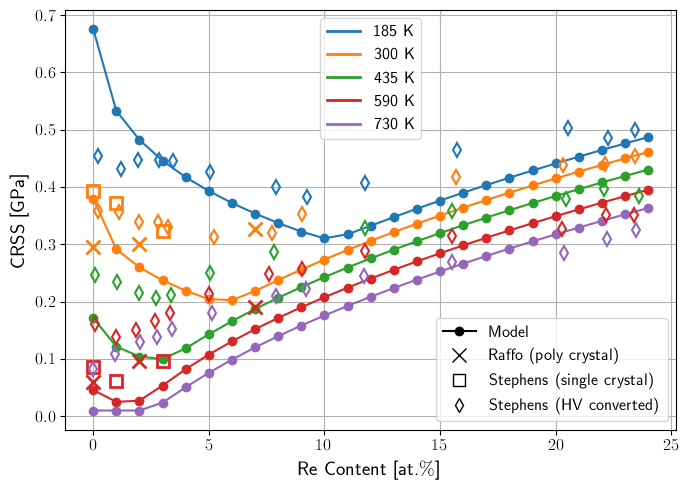

In [ ]:
# Stephens data
ksi_to_GPa = 0.006895
Re_exp = np.array([0, 1, 3])
WRe_150 = np.array([95, 82, 88])* ksi_to_GPa
WRe_300 = np.array([57, 54, 47])* ksi_to_GPa
WRe_590 = np.array([12.5, 9, 14])* ksi_to_GPa
Stephens_data = {
    # 150: WRe_150,
    300: WRe_300,
    590: WRe_590
}

# Raffo data
# T_exp = np.array([77, 200, 300, 600])
T_exp = np.array([300, 590])
Re_conc = np.array([0, 2, 7])  # at.%
sigma_yield_MPa = np.array([
    # [1350, 1240, 1170],   # 77 K
    # [ 1090, 1030, 960],   # 150 K
    # [ 890,  880,  870],   # 200 K
    [ 590,  600,  655],   # 300 K
    [ 120,  193,  380]    # 590 K
])
sigma_yield_GPa = sigma_yield_MPa / 1000.0 / 2 # 2 for polycrystal to single crystal conversion, assuming Taylor factor ~2

# Hardness data
hv_path = "HVdata.xlsx"   # or "/mnt/data/HVdata.xlsx" in this sandbox
df_raw = pd.read_excel(hv_path, header=None)
records = []
for _, row in df_raw.iterrows():
    T = row.iloc[0]
    if pd.isna(T):
        continue
    for j in range(1, df_raw.shape[1], 2):
        re_at = row.iloc[j]
        hv    = row.iloc[j+1] if j+1 < df_raw.shape[1] else np.nan
        if pd.isna(re_at) or pd.isna(hv):
            continue
        records.append({"T_K": float(T), "Re_atpct": float(re_at), "HV": float(hv)})
hv_long = pd.DataFrame(records)


# ---------------------------
# plot CRSS vs Re (legend = T) 
# ---------------------------
plt.figure(figsize=(7,5))
c_atpct = np.array(c_sol_array) * 100.0 
for j, T in enumerate(T_array):
    y = [CRSS_low[c][j] for c in c_sol_array]   
    plt.plot(c_atpct, y, "-o", label=f"T = {T} K")

ax = plt.gca()
temp_lines = ax.get_lines()  # lines currently on the axis (your model curves)
color_by_temp = {int(T): line.get_color() for T, line in zip(T_array, temp_lines)}

# ==== Raffo data ====
for i, T in enumerate(T_exp):
    col = color_by_temp.get(int(T), 'k')  # fallback color
    ax.plot(Re_conc, sigma_yield_GPa[i],
            marker='x', linestyle='None',
            color=col, markersize=10, markeredgewidth=2,
            label=f'Raffo {int(T)} K')
    
# ==== Stephens data ====
for T, yvals in Stephens_data.items():
    col = color_by_temp.get(int(T), 'k')  # match simulation color
    ax.plot(Re_exp, yvals,
            marker='s', linestyle='None',
            markersize=9,
            markerfacecolor='none',
            markeredgecolor=col,
            markeredgewidth=2,
            color=col,
            label=f'Stephens {T} K')

# ====`Hardness data ====
HV_to_MPa = 9.807   # 1 HV = 1 kgf/mm^2 = 9.807 MPa
C_Tabor   = 3.0     # sigma_y ≈ H/C
M_taylor  = 3.2    # polycrystal Taylor factor (typical ballpark)
hv_long["H_MPa"]        = hv_long["HV"] * HV_to_MPa
hv_long["sigma_y_MPa"]  = hv_long["H_MPa"] / C_Tabor
hv_long["sigma_y_GPa"]  = hv_long["sigma_y_MPa"] / 1000.0
# two CRSS interpretations:
hv_long["CRSS_poly_GPa"]   = (hv_long["sigma_y_MPa"] / M_taylor) / 1000.0   # tau = sigma/M
# sort for plotting
hv_long = hv_long.sort_values(["Re_atpct", "T_K"]).reset_index(drop=True)
ycol = "CRSS_poly_GPa"      # or "CRSS_single_GPa"
for T in sorted(hv_long["T_K"].unique()):
    subT = hv_long[np.isclose(hv_long["T_K"], T)]
    col = color_by_temp.get(int(round(T)), "k")
    ax.plot(subT["Re_atpct"], subT[ycol],
            marker="d", linestyle="None",
            color=col, markersize=7,
            markerfacecolor="none", markeredgewidth=1.5,
            label=f"HV {int(round(T))} K")

plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.xlabel(rf"Re Content [at.$\%$]", fontsize=14)
plt.ylabel("CRSS [GPa]",fontsize=14)
plt.grid(True)
# plt.legend()

# ----------------------------
# 1) Temperature legend (colors)
# ----------------------------
temp_handles = []
for T in sorted(set(list(T_array) + list(T_exp) + list(hv_long["T_K"].unique()))):
    if int(T) in color_by_temp:
        col = color_by_temp[int(T)]
        temp_handles.append( Line2D([0], [0], color=col, lw=2, label=f"{int(T)} K") )
legend_temp = ax.legend( handles=temp_handles, loc="upper center", frameon=True, fontsize=12 )
ax.add_artist(legend_temp)  # keep this legend
# ----------------------------
# 2) Data-type legend (markers)
# ----------------------------
marker_handles = [
    Line2D([0], [0], marker='o', color='k', linestyle='-', label='Model'),
    Line2D([0], [0], marker='x', color='k', linestyle='None', markersize=10, label='Raffo (poly crystal)'),
    Line2D([0], [0], marker='s', color='k', linestyle='None', markerfacecolor='none', markersize=9, label='Stephens (single crystal)'),
    Line2D([0], [0], marker='d', color='k', linestyle='None', markerfacecolor='none', markersize=7, label='Stephens (HV converted)')
                ]
ax.legend( handles=marker_handles, loc="lower right", frameon=True , fontsize=12) 
plt.tight_layout()
plt.savefig("Figures/CRSSvRe.png", dpi=300)
plt.show()



# # ---------------------------
# # plot CRSS vs Temperature (legend = Re content)
# # ---------------------------
# plt.figure(figsize=(7,5))
# T_vals = np.array(T_array)
# for i, c_sol in enumerate(c_sol_array):
#     # pick which strain-rate CRSS you want
#     y = CRSS_low[c_sol]      # use CRSS_high[c_sol] for the other strain rate
#     label = f"{int(round(c_sol*100))} at.% Re"
#     plt.plot(T_vals, y, "-o", label=label)
# plt.xlabel("Temperature [K]")
# plt.ylabel("CRSS [GPa]")
# plt.grid(True)
# # plt.legend()
# plt.tight_layout()
# plt.savefig("Figures/CRSSvT.png", dpi=300)
# plt.show()

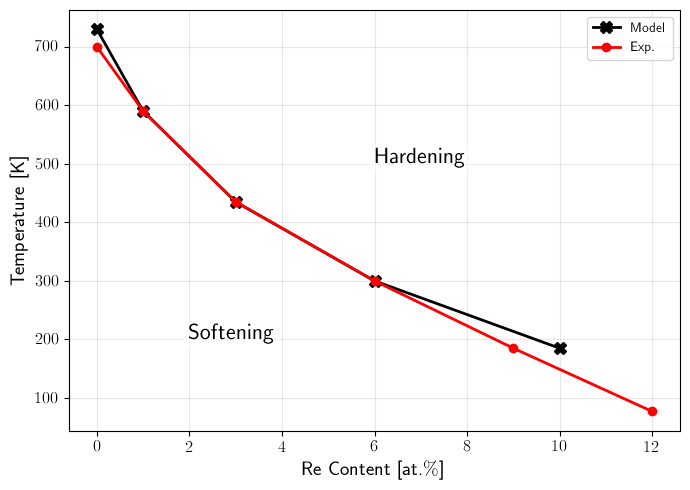

In [ ]:
# ---------------------------
# rows = concentration, cols = temperature
# ---------------------------
c_vals   = np.array(c_sol_array) * 100.0          # at.% on x-axis
T_vals   = np.array(T_array, dtype=float)         # K on y-axis
CRSS_grid = np.array([[CRSS_low[c][j] for j in range(len(T_vals))] for c in c_sol_array], dtype=float)  # [GPa], shape (Nc, NT)

plt.figure(figsize=(7, 5))
# ---------------------------
# For each temperature: find concentration that minimizes CRSS
# ---------------------------
imin_c = np.nanargmin(CRSS_grid, axis=0)         
c_minline = c_vals[imin_c]                       
plt.plot(c_minline, T_vals, 'k-X', lw=2, ms=8, label=rf'Model')

# --- experimental points ---
T_min_exp = np.array([77, 185, 300, 435, 590, 700], dtype=float)   # K
c_min_exp = np.array([12, 9, 6, 3, 1, 0], dtype=float)            # at.%
plt.plot(c_min_exp, T_min_exp, 'r-o', lw=2, ms=6, label='Exp.')


plt.text(6, 500, "Hardening",
         fontsize=16, weight='bold',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.text(2, 200, "Softening",
         fontsize=16, weight='bold',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.xlabel(rf"Re Content [at.$\%$]", fontsize=14)
plt.ylabel("Temperature [K]", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/T_vs_Re_minCRSS_line.png", dpi=300)
plt.show()

# CRSS_minline = CRSS_grid[imin_c, np.arange(len(T_vals))] 
# for T, cmin, crssmin in zip(T_vals, c_minline, CRSS_minline):
#     print(f"T = {T:6.1f} K : min CRSS at Re = {cmin:5.1f} at.%  (CRSS = {crssmin:.4g} GPa)")